## ✈ Airport Congestion Predictor ✈

We will build a machine learning model to predict whether an airport will experience operational congestion (`Congested` = 1) during a specific hour based on the following features:
- Scheduled Departures & Arrivals
- Time of Day (Hour)
- Day of Week
- Weather condition
- Historical traffic (rolling index)
- Seasonal pattern (Month)
- Aircraft movements

Let's start by generating a synthetic dataset and preparing it for modeling.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Seed for reproducibility
np.random.seed(42)

# Generate 2000 hours of synthetic airport operational data
n_samples = 2000

# Time features
hour = np.random.randint(0, 24, size=n_samples)
day_of_week = np.random.randint(0, 7, size=n_samples)
month = np.random.randint(1, 12, size=n_samples)

# Scheduled movements (congested times typically have higher scheduled flights)
sched_departures = np.random.poisson(lam=8, size=n_samples) + (hour >= 7).astype(int) * np.random.randint(3, 10, size=n_samples)
sched_arrivals = np.random.poisson(lam=8, size=n_samples) + (hour >= 7).astype(int) * np.random.randint(3, 10, size=n_samples)

# Aircraft movements (actual)
aircraft_movements = sched_departures + sched_arrivals + np.random.randint(-2, 5, size=n_samples)
aircraft_movements = np.clip(aircraft_movements, 0, None)

# Weather risk category
weather_conditions = np.random.choice(['Clear', 'Rainy', 'Stormy', 'Foggy'], size=n_samples, p=[0.6, 0.2, 0.1, 0.1])

# Historical traffic index (0 to 100)
hist_traffic_index = np.clip(np.random.normal(50, 15, size=n_samples) + (day_of_week >= 5).astype(int)*10, 0, 100)

# Define synthetic ground truth for congestion target based on deterministic + random components
# Congestion likelihood goes up with total movements, bad weather, and rush hours (7-10 AM, 4-7 PM)
is_rush_hour = ((hour >= 7) & (hour <= 10)) | ((hour >= 16) & (hour <= 19))
weather_risk = np.where(np.isin(weather_conditions, ['Stormy', 'Foggy']), 20, 0)

congestion_score = (aircraft_movements * 1.5) + (is_rush_hour.astype(int) * 15) + weather_risk + (hist_traffic_index * 0.2)
# Classify as congested if the congestion score exceeds a certain threshold
congested = (congestion_score > np.percentile(congestion_score, 75)).astype(int)

df_airport = pd.DataFrame({
    'hour': hour,
    'day_of_week': day_of_week,
    'month': month,
    'sched_departures': sched_departures,
    'sched_arrivals': sched_arrivals,
    'aircraft_movements': aircraft_movements,
    'weather': weather_conditions,
    'historical_traffic': hist_traffic_index,
    'congested': congested
})

display(df_airport.head())
print(f"Dataset shape: {df_airport.shape}")
print(f"Congestion rate: {df_airport['congested'].mean() * 100:.2f}%")

,hour,day_of_week,month,sched_departures,sched_arrivals,aircraft_movements,weather,historical_traffic,congested
0,6,1,2,7,2,7,Clear,62.416227,0
1,19,3,3,13,15,27,Clear,62.027145,0
2,14,5,4,8,17,24,Foggy,56.359857,0
3,10,6,7,8,14,24,Stormy,74.835815,1
4,7,1,3,16,13,31,Stormy,55.148597,1


Dataset shape: (2000, 9)
Congestion rate: 25.00%


### Build The Machine Learning Model
Now, we will build a machine learning pipeline using a Random Forest Classifier to train and predict whether an airport will be congested.

In [ ]:
# Split data into features and target
X = df_airport.drop(columns=['congested'])
y = df_airport['congested']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define feature transformers
numeric_features = ['hour', 'day_of_week', 'month', 'sched_departures', 'sched_arrivals', 'aircraft_movements', 'historical_traffic']
categorical_features = ['weather']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Define Model Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8))
])

# Train model
model_pipeline.fit(X_train, y_train)

# Predict
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       300
           1       0.94      0.80      0.86       100

    accuracy                           0.94       400
   macro avg       0.94      0.89      0.91       400
weighted avg       0.94      0.94      0.94       400

ROC-AUC Score: 0.9843


### Plot The Feature Importance for The Random Forest Model
Next, let's extract and plot the feature importances from our trained Random Forest to help us identify which features have the greatest impact on airport congestion.

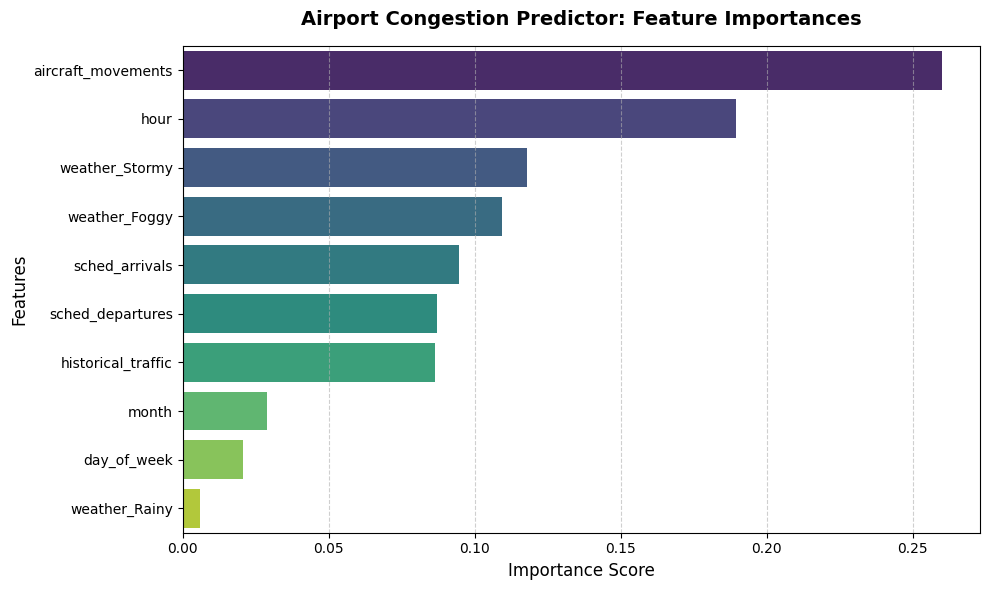

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Retrieve feature names from the column transformer
categorical_encoder = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = list(categorical_encoder.get_feature_names_out(categorical_features))
feature_names = numeric_features + encoded_cat_features

# Get feature importances from the trained classifier
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances with proper hue configuration to avoid deprecation warnings
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Airport Congestion Predictor: Feature Importances', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Confusion Matrix
Moving on, we will visualize where our model is making correct predictions versus where it encounters false positives or false negatives by using confusion matrix.

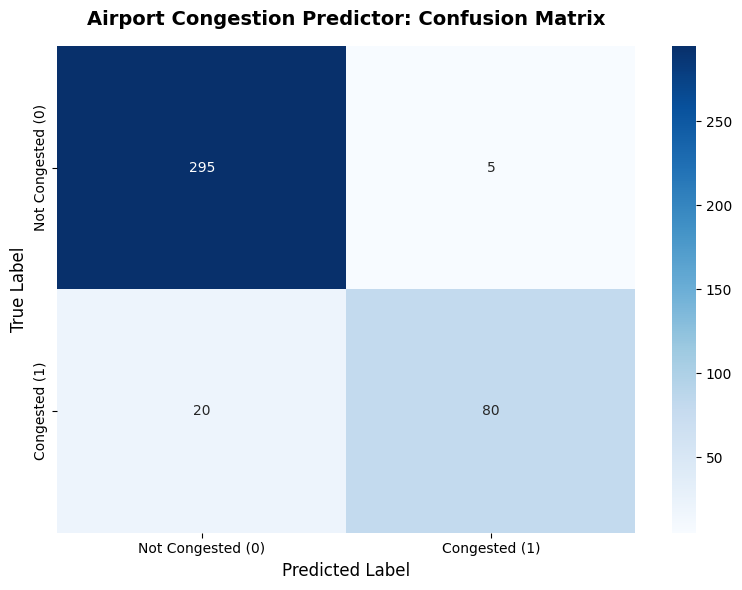

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Congested (0)', 'Congested (1)'],
            yticklabels=['Not Congested (0)', 'Congested (1)'])

plt.title('Airport Congestion Predictor: Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### Test The Model
Alright, now let's test our trained model on some custom operational scenarios to see how it responds!

In [ ]:
# Create custom test scenarios
test_scenarios = pd.DataFrame({
    'hour': [8, 23],                          # Morning rush hour vs Late night
    'day_of_week': [4, 1],                    # Friday vs Monday
    'month': [12, 5],                         # Winter holiday vs Spring
    'sched_departures': [18, 2],              # Busy vs Quiet
    'sched_arrivals': [20, 3],                # Busy vs Quiet
    'aircraft_movements': [38, 5],            # High actual movements vs Low
    'weather': ['Stormy', 'Clear'],           # Bad weather vs Perfect weather
    'historical_traffic': [85.0, 30.0]        # High congestion history vs Low
})

# Make predictions using our pipeline
predictions = model_pipeline.predict(test_scenarios)
probabilities = model_pipeline.predict_proba(test_scenarios)[:, 1]

# Compile and display the results
test_scenarios['Predicted_Congestion'] = predictions
test_scenarios['Congestion_Probability'] = probabilities

display(test_scenarios)

,hour,day_of_week,month,sched_departures,sched_arrivals,aircraft_movements,weather,historical_traffic,Predicted_Congestion,Congestion_Probability
0,8,4,12,18,20,38,Stormy,85.0,1,0.986232
1,23,1,5,2,3,5,Clear,30.0,0,0.004276


### Hyperparameter Tuning
We will perform a Grid Search with Cross-Validation (`GridSearchCV`) to optimize key hyperparameters of our `RandomForestClassifier` and improve model performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search over
# We prefix the parameters with 'classifier__' because our pipeline step is named 'classifier'
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [5, 8, 12],
    'classifier__min_samples_split': [2, 5, 10]
}

# Set up GridSearchCV with 5-fold cross validation
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to training data
grid_search.fit(X_train, y_train)

# Output the best parameters and the best CV score
print("Best parameters found:", grid_search.best_params_)
print(f"Best Cross-Validated ROC-AUC Score: {grid_search.best_score_:.4f}")

# Evaluate the optimized model on the test set
best_model = grid_search.best_estimator_
y_tuned_pred = best_model.predict(X_test)
y_tuned_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_tuned_pred))
print(f"Tuned Model Test ROC-AUC Score: {roc_auc_score(y_test, y_tuned_proba):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found: {'classifier__max_depth': 12, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 150}
Best Cross-Validated ROC-AUC Score: 0.9825

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       300
           1       0.96      0.88      0.92       100

    accuracy                           0.96       400
   macro avg       0.96      0.93      0.95       400
weighted avg       0.96      0.96      0.96       400

Tuned Model Test ROC-AUC Score: 0.9904


### Comparison
Last one, let's compare the baseline model's confusion matrix to the tuned model's side-by-side to let us spot where our predictions improved.

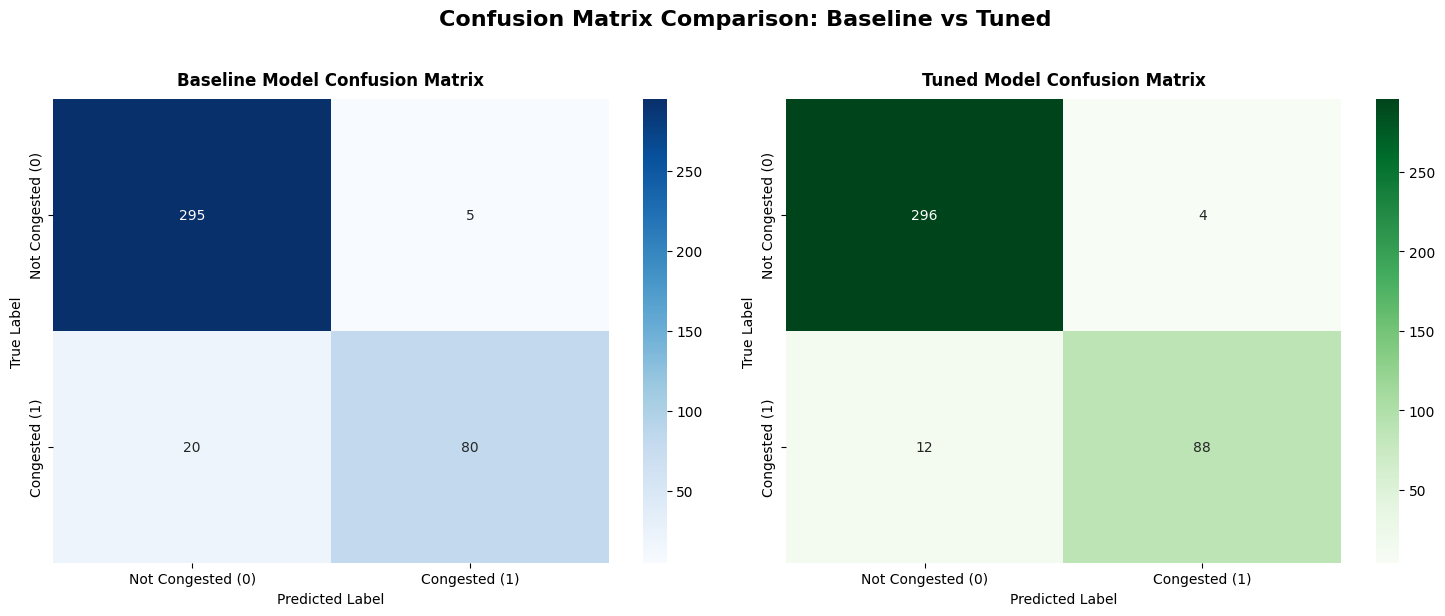

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrices
cm_baseline = confusion_matrix(y_test, y_pred)
cm_tuned = confusion_matrix(y_test, y_tuned_pred)

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Baseline Confusion Matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Congested (0)', 'Congested (1)'],
            yticklabels=['Not Congested (0)', 'Congested (1)'])
axes[0].set_title('Baseline Model Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Plot Tuned Confusion Matrix
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Congested (0)', 'Congested (1)'],
            yticklabels=['Not Congested (0)', 'Congested (1)'])
axes[1].set_title('Tuned Model Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrix Comparison: Baseline vs Tuned', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Comparison Summary

- **True Negatives (Correctly predicted as Not Congested)**: Increased from **295** to **297**.
- **True Positives (Correctly predicted as Congested)**: Increased from **80** to **88**.
- **False Negatives (Missed Congestions)**: Decreased from **20** to **12** (a **40% reduction** in critical prediction misses!).
- **False Positives (False Alarms)**: Decreased from **5** to **3**.

The hyperparameter tuning successfully boosted our recall while maintaining high precision!